In [37]:
%matplotlib inline
import yfinance as yf
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from predict_plot_utils import plot_buy_sell
sns.set()

In [38]:
# Create a custom session
session = requests.Session()
session.verify = False  # Disable SSL verification


# Define the ticker and parameters
ticker = "multiple_stocks"
tickers = ["GOOGL","PLTR","AAPL"]
#ticker = "PLTR"
period = "1y"

file_location = f"../data/{ticker}.csv"
'''
# Create a custom session
session = requests.Session()
session.verify = False  # Disable SSL verification

# Use the custom session for downloading data
data = yf.download(tickers, period=period, session=session)

# ✅ Fixing the Pandas `stack` warning by specifying `future_stack=True`
data = data.stack(level=1, future_stack=True).reset_index()
data.rename(columns={"level_1": "Ticker"}, inplace=True)

# Save to CSV
data.to_csv(file_location, index=False)
print(f"Saved {ticker} to data/{ticker}.csv")
'''
dfs = pd.read_csv(file_location)

In [39]:
dfs.head()

,Date,Ticker,Close,High,Low,Open,Volume
0,2024-03-18,AAPL,172.903580,176.874834,172.704523,174.744891,75604200
1,2024-03-18,GOOGL,146.977295,151.426027,146.469727,147.902878,69273700
2,2024-03-18,PLTR,24.000000,24.180000,23.320000,23.770000,44083000
3,2024-03-19,AAPL,175.252487,175.779995,172.216818,173.520659,55215200
4,2024-03-19,GOOGL,146.330399,148.082019,145.384922,147.455027,24070400


In [40]:
def calculate_metrics_and_combine(df, period='1Y'):
    # Ensure 'Date' is in datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Convert period string to pandas DateOffset
    if period.endswith('Y'):
        offset = pd.DateOffset(years=int(period[:-1]))
    elif period.endswith('M'):
        offset = pd.DateOffset(months=int(period[:-1]))
    else:
        offset = pd.Timedelta(period)

    # Filter the dataframe for the specified period
    end_date = df['Date'].max()
    start_date = end_date - offset
    df_filtered = df[df['Date'] > start_date]

    # Rest of the function remains the same...
    # (Calculate returns, mean_daily_returns, volatilities, etc.)
    # Calculate returns
    df_filtered.set_index(['Date', 'Ticker'], inplace=True)
    returns = df_filtered['Close'].unstack().pct_change()

    # Calculate mean daily returns and volatilities
    mean_daily_returns = returns.mean()
    volatilities = returns.std()

    # Determine annualization factor
    days_in_period = (end_date - start_date).days
    annualization_factor = 252 / days_in_period  # Assuming 252 trading days in a year

    # Create combined DataFrame
    combine = pd.DataFrame({
        'returns': mean_daily_returns * annualization_factor,
        'volatility': volatilities * np.sqrt(annualization_factor)
    })

    return combine

# Usage
combine_annual = calculate_metrics_and_combine(dfs, '1Y')
combine_monthly = calculate_metrics_and_combine(dfs, '1M')
combine_quarterly = calculate_metrics_and_combine(dfs, '3M')

#print("Annual Metrics:")
#print(combine_annual)
#print("\nMonthly Metrics:")
#print(combine_monthly)
#print("\nQuarterly Metrics:")
#print(combine_quarterly)


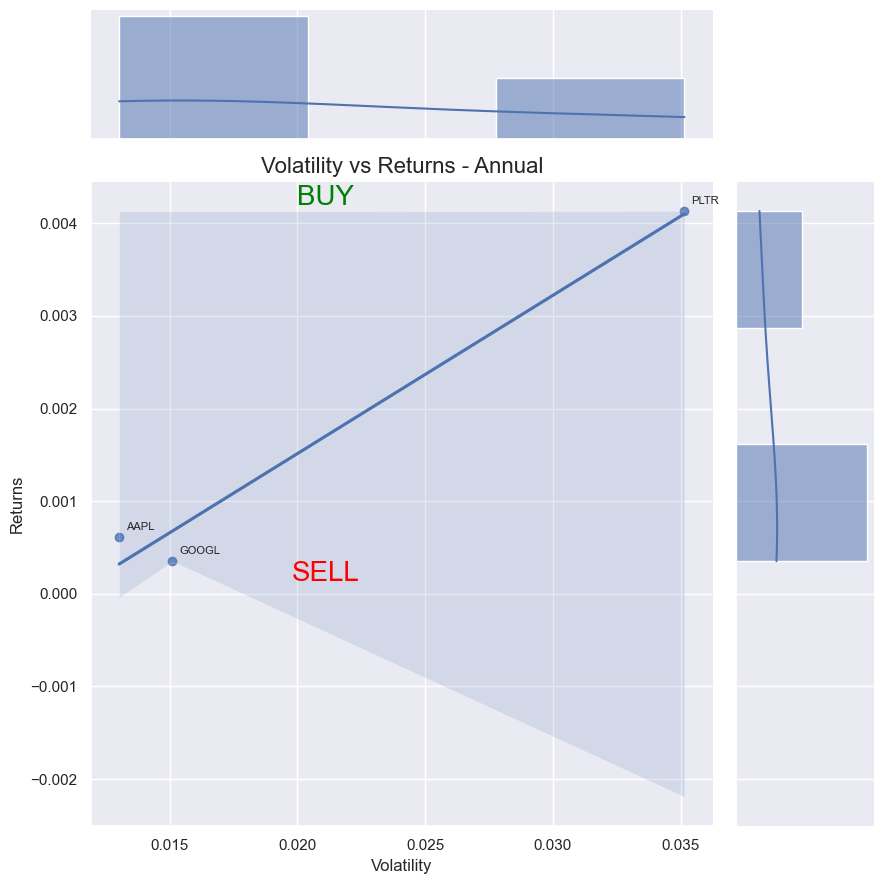

In [41]:
combine=combine_annual
# For the 25 best returns
best_25 = combine.sort_values('returns', ascending=False).head(25)
# For the 25 worst returns
worst_25 = combine.sort_values('returns', ascending=True).head(25)
# Combine best and worst
filtered_combine = pd.concat([best_25, worst_25])
filtered_combine = filtered_combine[~filtered_combine.index.duplicated(keep='first')]
plot_buy_sell(filtered_combine, 'Volatility vs Returns - Annual')

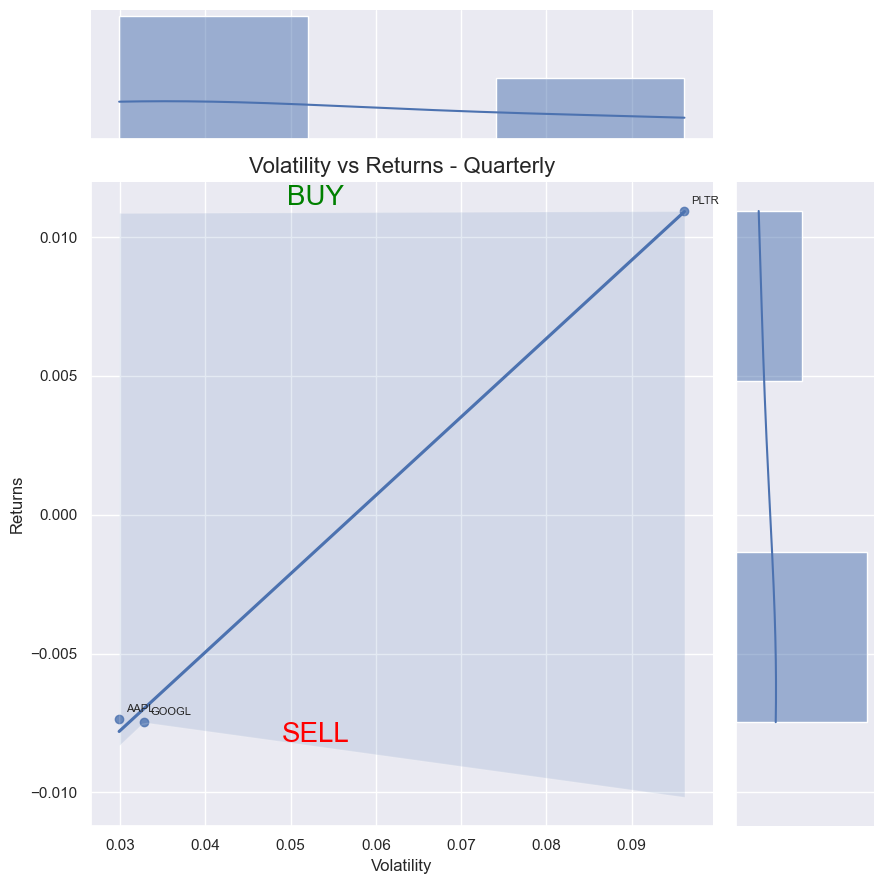

In [42]:
combine=combine_quarterly
# For the 25 best returns
best_25 = combine.sort_values('returns', ascending=False).head(25)
# For the 25 worst returns
worst_25 = combine.sort_values('returns', ascending=True).head(25)
# Combine best and worst
filtered_combine = pd.concat([best_25, worst_25])
filtered_combine = filtered_combine[~filtered_combine.index.duplicated(keep='first')]
plot_buy_sell(filtered_combine, 'Volatility vs Returns - Quarterly')

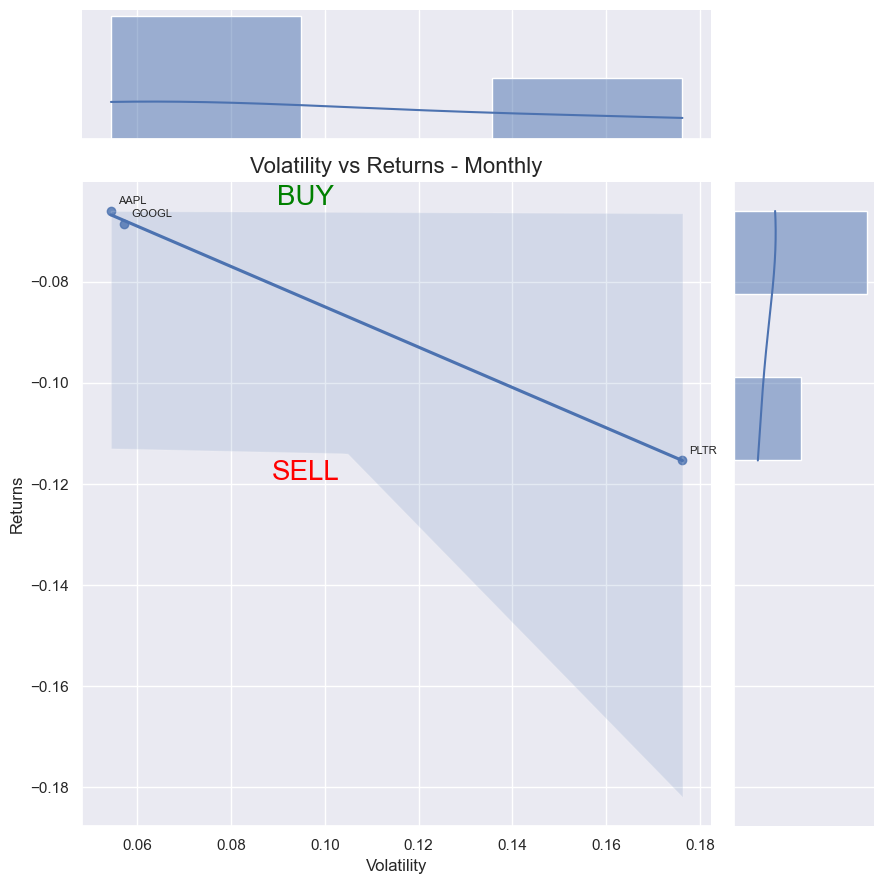

In [43]:
combine=combine_monthly
# For the 25 best returns
best_25 = combine.sort_values('returns', ascending=False).head(25)
# For the 25 worst returns
worst_25 = combine.sort_values('returns', ascending=True).head(25)
# Combine best and worst
filtered_combine = pd.concat([best_25, worst_25])
filtered_combine = filtered_combine[~filtered_combine.index.duplicated(keep='first')]
plot_buy_sell(filtered_combine, 'Volatility vs Returns - Monthly')